In [1]:
import pandas as pd

In [2]:
data=pd.read_csv("smartcart_customers.csv")

In [3]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
data.shape

(2240, 22)

In [5]:
data.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [6]:
#handling missing values
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy="mean")
data[["Income"]]=imputer.fit_transform(data[["Income"]])

In [7]:
data.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [9]:
#Encoding 
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
data["Education"]=le.fit_transform(data["Education"])
data["Dt_Customer"]=le.fit_transform(data["Dt_Customer"])
cols=["Marital_Status"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(data[cols]) #produces numpy array
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=data.index)
data=pd.concat([data.drop(columns=cols),encoded_df],axis=1)

In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Education                2240 non-null   int64  
 3   Income                   2240 non-null   float64
 4   Kidhome                  2240 non-null   int64  
 5   Teenhome                 2240 non-null   int64  
 6   Dt_Customer              2240 non-null   int64  
 7   Recency                  2240 non-null   int64  
 8   MntWines                 2240 non-null   int64  
 9   MntFruits                2240 non-null   int64  
 10  MntMeatProducts          2240 non-null   int64  
 11  MntFishProducts          2240 non-null   int64  
 12  MntSweetProducts         2240 non-null   int64  
 13  MntGoldProds             2240 non-null   int64  
 14  NumDealsPurchases        2240 non-n

In [11]:
data.head()

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,Complain,Response,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,2,58138.0,0,0,80,58,635,88,...,7,0,1,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2174,1954,2,46344.0,1,1,157,38,11,1,...,5,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,4141,1965,2,71613.0,0,0,444,26,426,49,...,4,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,6182,1984,2,26646.0,1,0,199,26,11,4,...,6,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5324,1981,4,58293.0,1,0,390,94,173,43,...,5,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [12]:
data.shape

(2240, 28)

In [13]:
#EDA
import seaborn as sns
corr_matrix=data.corr()

In [14]:
corr_matrix

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,Complain,Response,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
ID,1.000000,0.000028,-0.003839,0.013036,0.002406,-0.002580,-0.030924,-0.046524,-0.022878,0.004600,...,-0.007446,0.033883,-0.021968,-0.032310,-0.017289,0.010007,-0.016558,0.009563,0.021937,0.002029
Year_Birth,0.000028,1.000000,-0.171390,-0.160942,0.230176,-0.352111,-0.008510,-0.019871,-0.157773,-0.017917,...,0.121139,-0.030128,0.021325,0.012819,-0.071774,0.051193,0.116978,-0.052258,-0.161370,0.010465
Education,-0.003839,-0.171390,1.000000,0.119974,-0.045564,0.118485,0.017878,-0.011728,0.197576,-0.080412,...,-0.040281,-0.050540,0.090819,0.019742,0.003453,-0.000163,-0.009675,-0.014840,0.040706,0.042699
Income,0.013036,-0.160942,0.119974,1.000000,-0.425176,0.019018,-0.031236,-0.003946,0.576789,0.428747,...,-0.549824,-0.027223,0.132756,-0.012374,0.007970,-0.016399,-0.025628,0.023288,0.031501,-0.004556
Kidhome,0.002406,0.230176,-0.045564,-0.425176,1.000000,-0.036133,-0.002199,0.008827,-0.496297,-0.372581,...,0.447846,0.040207,-0.080008,0.037813,-0.019199,0.017403,0.019779,0.006373,-0.073760,-0.024669
Teenhome,-0.002580,-0.352111,0.118485,0.019018,-0.036133,1.000000,0.005078,0.016198,0.004846,-0.176764,...,0.134884,0.003138,-0.154446,0.010791,0.052613,0.007749,-0.095925,0.025038,0.045093,0.027112
Dt_Customer,-0.030924,-0.008510,0.017878,-0.031236,-0.002199,0.005078,1.000000,0.011171,0.000855,-0.020819,...,0.026401,-0.011827,-0.008263,-0.008772,0.006295,0.010341,0.001510,-0.010939,-0.014285,0.008668
Recency,-0.046524,-0.019871,-0.011728,-0.003946,0.008827,0.016198,0.011171,1.000000,0.016064,-0.004306,...,-0.021445,0.013231,-0.198437,-0.023746,0.004434,-0.022757,0.007158,0.020363,0.000218,-0.047603
MntWines,-0.022878,-0.157773,0.197576,0.576789,-0.496297,0.004846,0.000855,0.016064,1.000000,0.389637,...,-0.320653,-0.039007,0.247254,-0.012979,0.021120,-0.010491,-0.024216,0.005077,0.036632,0.001605
MntFruits,0.004600,-0.017917,-0.080412,0.428747,-0.372581,-0.176764,-0.020819,-0.004306,0.389637,1.000000,...,-0.418383,-0.005166,0.125289,-0.020539,0.009612,-0.011304,0.007002,-0.014155,0.032211,-0.017518


<Axes: >

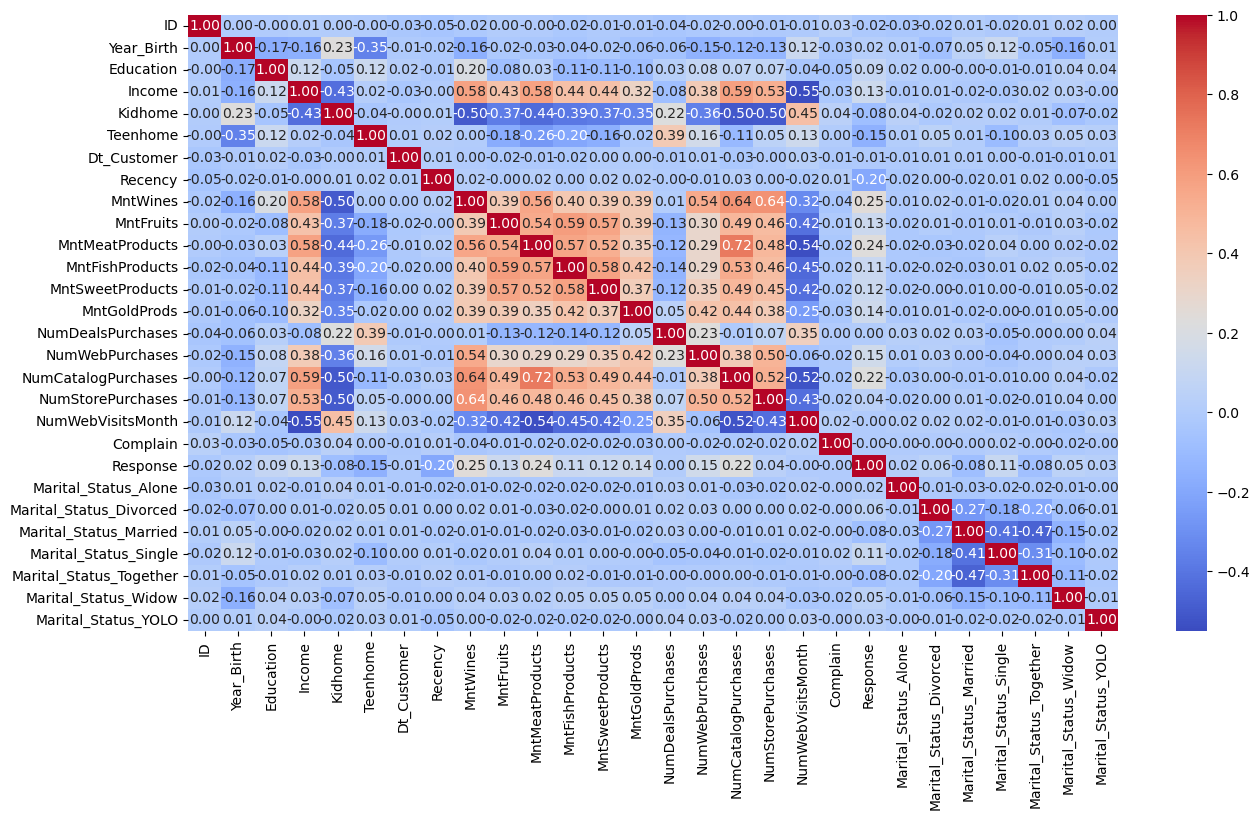

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

In [17]:
X=data.drop(["ID","Dt_Customer","Marital_Status_Alone","Marital_Status_YOLO","Complain"],axis=1)

In [18]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [19]:
X_scaled

array([[-0.98534473, -0.35014129,  0.23532677, ...,  1.91485422,
        -0.59109863, -0.18867619],
       [-1.23573295, -0.35014129, -0.23582624, ...,  1.91485422,
        -0.59109863, -0.18867619],
       [-0.3176428 , -0.35014129,  0.77363327, ..., -0.52223297,
         1.69176504, -0.18867619],
       ...,
       [ 1.01776106, -0.35014129,  0.18910632, ..., -0.52223297,
        -0.59109863, -0.18867619],
       [-1.06880747,  0.53910643,  0.67903514, ..., -0.52223297,
         1.69176504, -0.18867619],
       [-1.23573295,  1.42835415,  0.02483795, ..., -0.52223297,
        -0.59109863, -0.18867619]])

In [20]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_scaled=pca.fit_transform(X_scaled)

<Axes: >

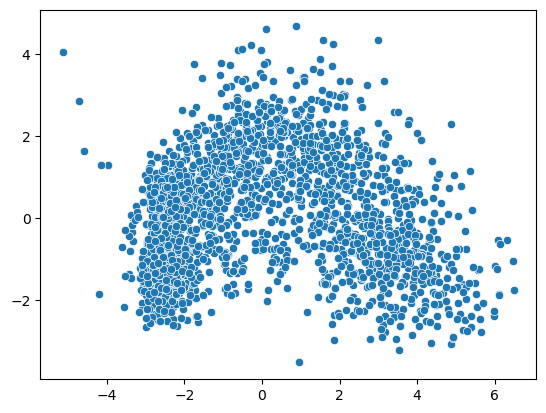

In [21]:
sns.scatterplot(x=pca_scaled[:,0],y=pca_scaled[:,1])

In [22]:
from sklearn.cluster import KMeans

In [27]:
#Kmeans
wcss=[]
for k in range(2,20):
    model=KMeans(n_clusters=k)
    model.fit_predict(X_scaled)
    wcss.append(model.inertia_)

<Axes: >

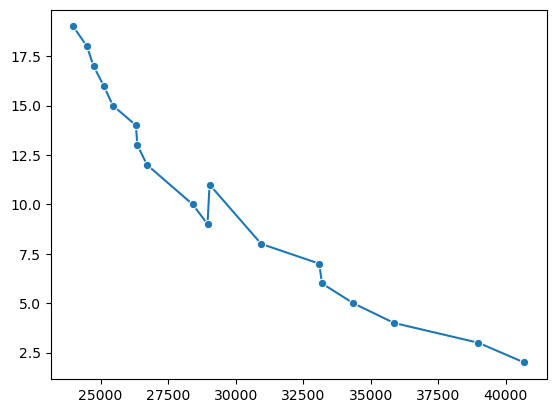

In [28]:
sns.lineplot(x=wcss,y=range(2,20),marker="o")

In [29]:
model=KMeans(n_clusters=4)
labels=model.fit_predict(X_scaled)

<Axes: >

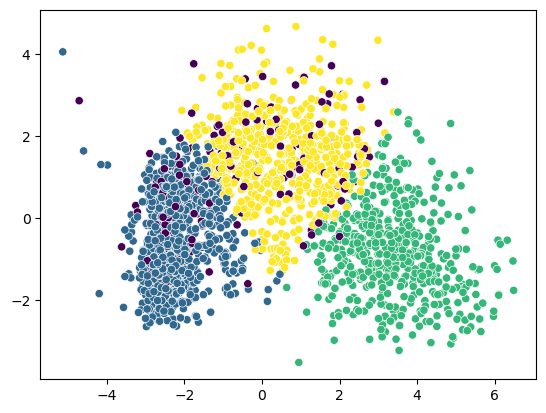

In [30]:
sns.scatterplot(x=pca_scaled[:,0],y=pca_scaled[:,1],c=labels)

In [34]:
#Hierarchical
from scipy.cluster.hierarchy import linkage,dendrogram

Text(0, 0.5, 'PC2')

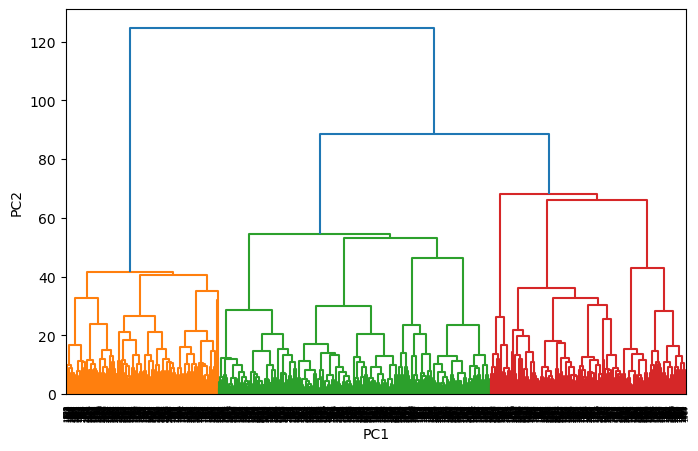

In [40]:
Z=linkage(X_scaled,method="ward")
plt.figure(figsize=(8,5))
dendrogram(Z)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [44]:
#we identify k=2
from sklearn.cluster import AgglomerativeClustering
model=AgglomerativeClustering(n_clusters=2)
labels=model.fit_predict(X_scaled)

<Axes: >

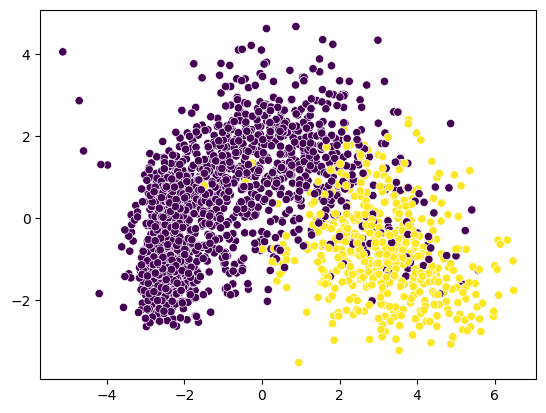

In [45]:
sns.scatterplot(x=pca_scaled[:,0],y=pca_scaled[:,1],c=labels)

In [55]:
#DBscan
from sklearn.cluster import DBSCAN
model=DBSCAN(
    eps=0.5,
    min_samples=5
)
labels=model.fit_predict(X_scaled)

<Axes: >

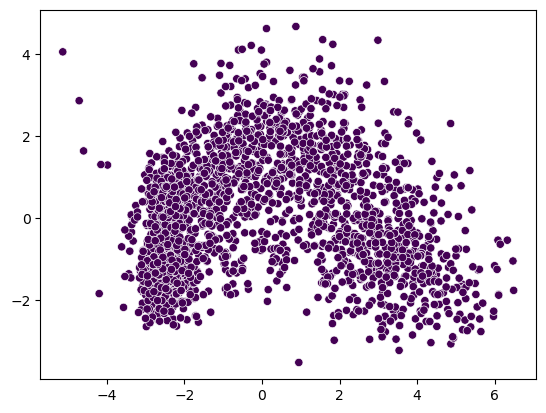

In [56]:
sns.scatterplot(x=pca_scaled[:,0],y=pca_scaled[:,1],c=labels)